In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from skimage.morphology import skeletonize
from skimage.measure import label
from scipy.signal import convolve2d

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

print(device)

mps


In [4]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model.load_state_dict(
    torch.load(
        "deeplabv3_resnet50_5000img.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Model Loaded Successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'deeplabv3_resnet50_5000img.pth'

In [5]:
test_id = "63019"   # ya common_ids[0] wali id

img = cv2.imread(
    f"train/{test_id}_sat.jpg"
)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img_rgb,
    (512,512)
)

x = img_resized.astype(np.float32)/255.0

x = torch.tensor(
    x.transpose(2,0,1)
).unsqueeze(0)

x = x.to(device)

with torch.no_grad():
    pred = model(x)

pred = torch.sigmoid(pred)

pred = pred.squeeze().cpu().numpy()

pred_binary = (pred > 0.2).astype(np.uint8)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Satellite")

plt.subplot(1,2,2)
plt.imshow(pred_binary,cmap="gray")
plt.title("Road Mask")

plt.show()

RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

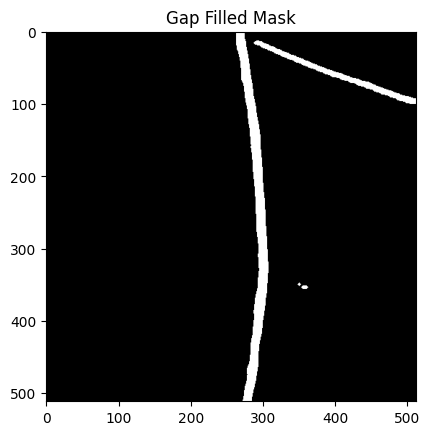

In [5]:
from scipy.ndimage import binary_dilation

fixed_mask = binary_dilation(
    pred_binary,
    iterations=2
)

plt.imshow(fixed_mask, cmap="gray")
plt.title("Gap Filled Mask")
plt.show()

skeleton = skeletonize(fixed_mask)

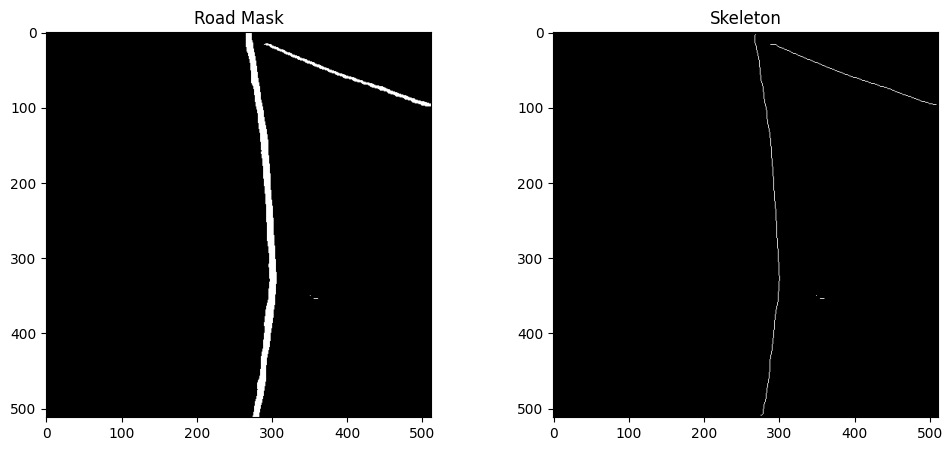

In [6]:
from skimage.morphology import skeletonize

road_mask = pred_binary.astype(bool)

skeleton = skeletonize(road_mask)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(pred_binary,cmap="gray")
plt.title("Road Mask")

plt.subplot(1,2,2)
plt.imshow(skeleton,cmap="gray")
plt.title("Skeleton")

plt.show()

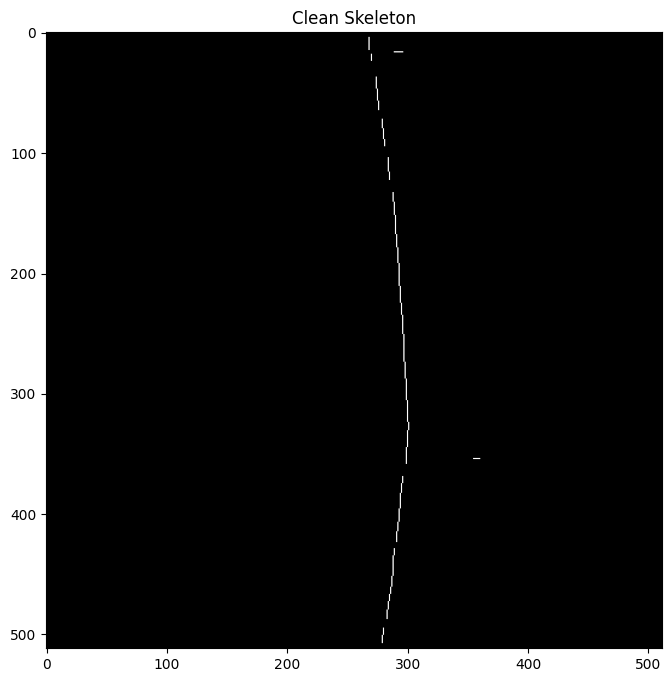

In [7]:
from skimage.morphology import remove_small_objects

clean_skeleton = remove_small_objects(
    skeleton,
    max_size=5
)

plt.figure(figsize=(8,8))
plt.imshow(clean_skeleton, cmap="gray")
plt.title("Clean Skeleton")
plt.show()

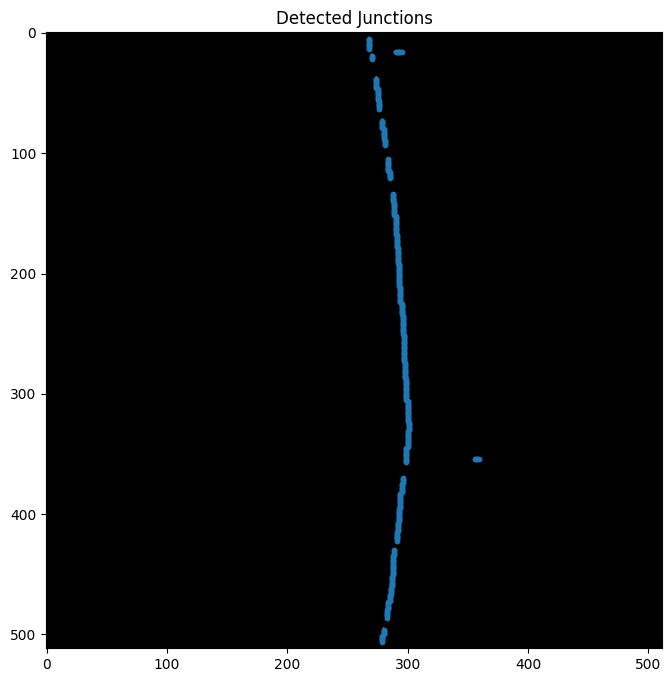

Junction Count: 432


In [8]:
from scipy.signal import convolve2d

sk = clean_skeleton.astype(np.uint8)

kernel = np.array([
    [1,1,1],
    [1,10,1],
    [1,1,1]
])

neighbors = convolve2d(
    sk,
    kernel,
    mode="same"
)

# neighbors >= 12 → pixel has 2+ skeleton neighbours (junction / bend)
# neighbors >= 13 → pixel has 3+ skeleton neighbours (T / cross junction)
junctions = (
    (sk == 1)
    &
    (neighbors >= 12)
)

plt.figure(figsize=(8,8))
plt.imshow(sk, cmap="gray")

plt.scatter(
    np.where(junctions)[1],
    np.where(junctions)[0],
    s=10
)

plt.title("Detected Junctions")
plt.show()

print(
    "Junction Count:",
    np.sum(junctions)
)

Junction Count: 432


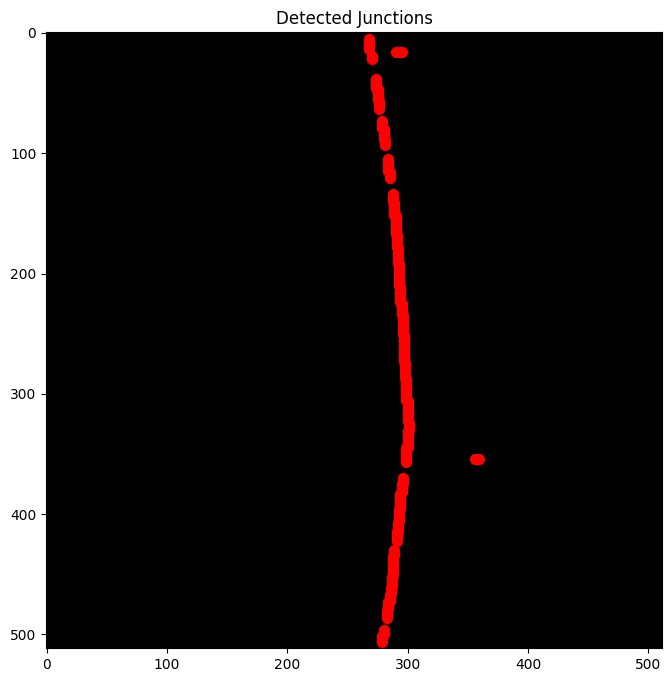

In [9]:
ys, xs = np.where(junctions)

print("Junction Count:", len(xs))

plt.figure(figsize=(8,8))
plt.imshow(sk, cmap="gray")

plt.scatter(
    xs,
    ys,
    c="red",
    s=50
)

plt.title("Detected Junctions")
plt.show()

In [10]:
from skimage.measure import label

labels = label(skeleton)

print(
    "Connected Components:",
    labels.max()
)

Connected Components: 4


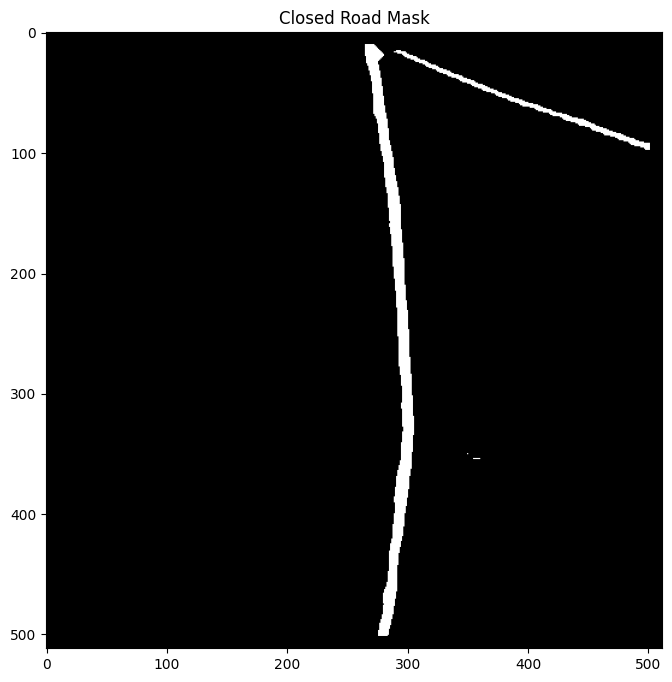

In [11]:
from scipy.ndimage import binary_closing

fixed_mask = binary_closing(
    pred_binary,
    iterations=10
)

plt.figure(figsize=(8,8))
plt.imshow(fixed_mask, cmap="gray")
plt.title("Closed Road Mask")
plt.show()

Connected Components: 4


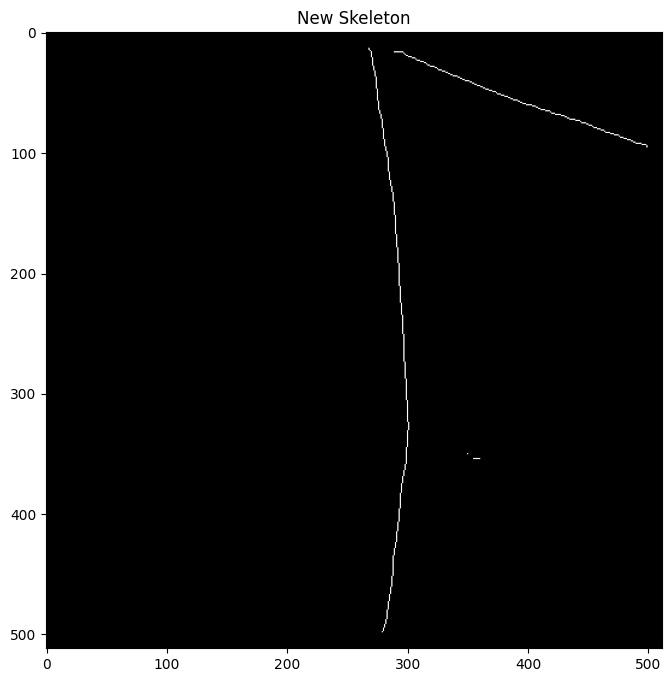

In [12]:
from skimage.morphology import skeletonize
from skimage.measure import label

new_skeleton = skeletonize(fixed_mask)

labels = label(new_skeleton)

print(
    "Connected Components:",
    labels.max()
)

plt.figure(figsize=(8,8))
plt.imshow(new_skeleton, cmap="gray")
plt.title("New Skeleton")
plt.show()